In [16]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import baltic as bt
import re
from collections import defaultdict
import pandas as pd
from scipy.stats import pearsonr
from scipy.stats import spearmanr

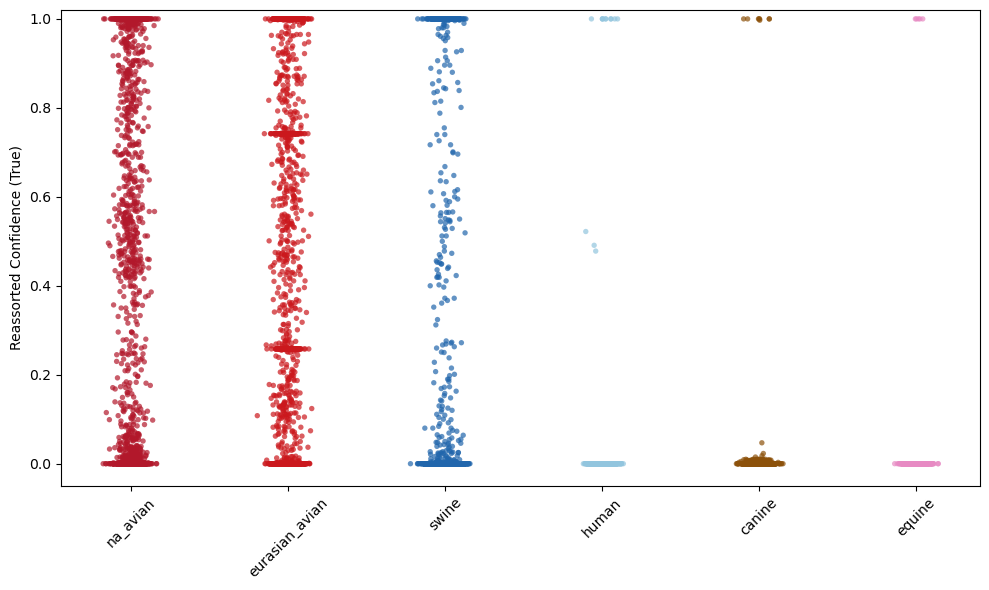

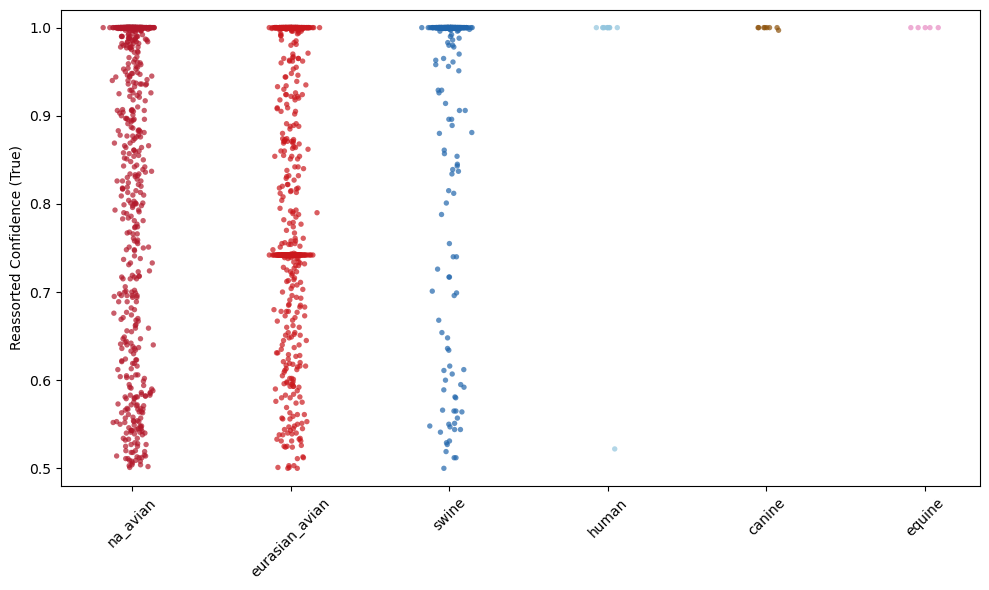

In [17]:
json_folder = "jsons"
clades = ['na_avian', 'eurasian_avian', 'swine', 'human', 'canine', 'equine']

colors = [
    "#b2182b", 
    "#cb181d", 
    "#2166ac",  
    "#92c5de",  
    "#8c510a", 
    "#e78ac3"
]

plot_data = {}
for clade in clades:
    file_path = os.path.join(json_folder, f"{clade}.json")
    with open(file_path, "r") as file:
        data = json.load(file)
    
    true_conf_values = [
        node_data["reassorted_confidence"].get("True", np.nan)
        for node_data in data["nodes"].values()
        if "reassorted_confidence" in node_data
    ]
    plot_data[clade] = [v for v in true_conf_values if not np.isnan(v)]

plt.figure(figsize=(10, 6))
for i, clade in enumerate(clades):
    y_values = plot_data[clade]
    x_values = np.random.normal(i + 1, 0.05, size=len(y_values))  # jitter
    plt.scatter(x_values, y_values, color=colors[i], s=15, alpha=0.7, edgecolors='none')

plt.xticks(range(1, len(clades) + 1), clades, rotation=45)
plt.ylim(-0.05, 1.02)
plt.ylabel("Reassorted Confidence (True)")
plt.tight_layout()
plt.show()

# y-axis starts at 0.5 ---
plt.figure(figsize=(10, 6))
for i, clade in enumerate(clades):
    y_values = [v for v in plot_data[clade] if v >= 0.5]
    x_values = np.random.normal(i + 1, 0.05, size=len(y_values))  # jitter
    plt.scatter(x_values, y_values, color=colors[i], s=15, alpha=0.7, edgecolors='none')
        
plt.xticks(range(1, len(clades) + 1), clades, rotation=45)
plt.ylim(0.48, 1.02)
plt.ylabel("Reassorted Confidence (True)")
plt.tight_layout()
plt.show()



In [18]:
json_folder = "jsons"
clades = ['na_avian', 'eurasian_avian', 'swine', 'human', 'canine', 'equine']

colors = [
    "#b2182b", 
    "#cb181d", 
    "#2166ac",  
    "#92c5de",  
    "#8c510a", 
    "#e78ac3"
]

plot_data = {}
for clade in clades:
    file_path = os.path.join(json_folder, f"{clade}.json")
    with open(file_path, "r") as file:
        data = json.load(file)
        
        
    true_conf_values = [
        node_data["reassorted_confidence"].get("True", np.nan)
        for node_data in data["nodes"].values()
        if "reassorted_confidence" in node_data
    ]
    plot_data[clade] = [v for v in true_conf_values if not np.isnan(v)]
    

In [19]:
# for clade in clades:

#     tree = f'plots/{clade}.nwk'

#     with open(tree, 'r') as file:
#         modified = file.read()

#     # removing commas between segments
#     modified = re.sub(r'rea=([^]]+)', lambda match: f'rea="{match.group(1).replace(",", "-")}"', modified)
    
#     modified = re.sub(r"'(NODE_\d+)'", r'\1', modified)

#     # removing quotation marks around node names
#     modified = re.sub(r"'(TS_NODE_\d+)'", r'\1', modified)
    
    
#     with open(tree, "w") as output_file:
#         output_file.write(modified.strip())

In [20]:
clades = ['h3nx','na_avian', 'eurasian_avian', 'swine', 'human', 'canine', 'equine']

plot_data = defaultdict(lambda: defaultdict(dict))

for clade in clades:

    mytree = bt.loadNewick(f'plots/{clade}.nwk', absoluteTime= False)
    
    for k in mytree.Objects:
        
        if k.is_leaf():
            plot_data[clade][k.name]["div"] = k.height
            plot_data[clade][k.name]["type"] = 'leaf'
            
        if k.is_node():
            plot_data[clade][k.traits["label"]]["div"] = k.height
            plot_data[clade][k.traits["label"]]["type"] = 'node'
            

    with open(f'jsons/{clade}.json', "r") as file:
        data = json.load(file)
        
    for name, node_data in data["nodes"].items():
        
        plot_data[clade][name]['support'] = node_data["reassorted_confidence"].get("True", np.nan)
        

In [21]:
# smaller height = closer to the root
# y-axis is support
# x-axis is height
# might need to flip

rows = []
for clade, nodes in plot_data.items():
    for name, vals in nodes.items():
        rows.append({
            "clade": clade,
            "name": name,
            "div": vals["div"],
            "type": vals["type"],
            "support": vals["support"]
        })

df = pd.DataFrame(rows)

df

# for clade, sub in df.groupby("clade"):
#     rho, p = spearmanr(sub["support"], sub["div"])
    
#     print(clade)
    
#     print(f"Spearman ρ = {rho:.3f}, p = {p:.3e}")
    
#     r, p = pearsonr(sub["support"], sub["div"])
#     print(f"Pearson r = {r:.3f}, p = {p:.3e}")
    
#     print("\n")


,clade,name,div,type,support
0,h3nx,TS_NODE_5259,0.00100,node,0.000
1,h3nx,TS_NODE_2305,0.00923,node,0.737
2,h3nx,TS_NODE_8,0.01299,node,0.736
3,h3nx,A/duck/Hokkaido/5/1977|1977-01-01,0.03043,leaf,0.000
4,h3nx,TS_NODE_7,0.02020,node,1.000
...,...,...,...,...,...
20834,equine,NODE_214,0.04370,node,0.000
20835,equine,A/equine/Switzerland/1118/1979|1979-01-01,0.04370,leaf,0.000
20836,equine,A/equine/Romania/1/1980|1980-01-01,0.04660,leaf,0.000
20837,equine,A/equine/France/1/1967|1967-01-01,0.04370,leaf,0.000


In [22]:
# for clade in df["clade"].unique():
#     subset = df[df["clade"] == clade]
#     plt.figure(figsize=(5,4))
#     plt.scatter(subset["div"], subset["support"], alpha=0.6)
#     plt.title(f"{clade}")
#     plt.xlabel("divergence from root")
#     plt.ylabel("reassortment support")
#     plt.grid(True, alpha=0.3)
#     plt.show()

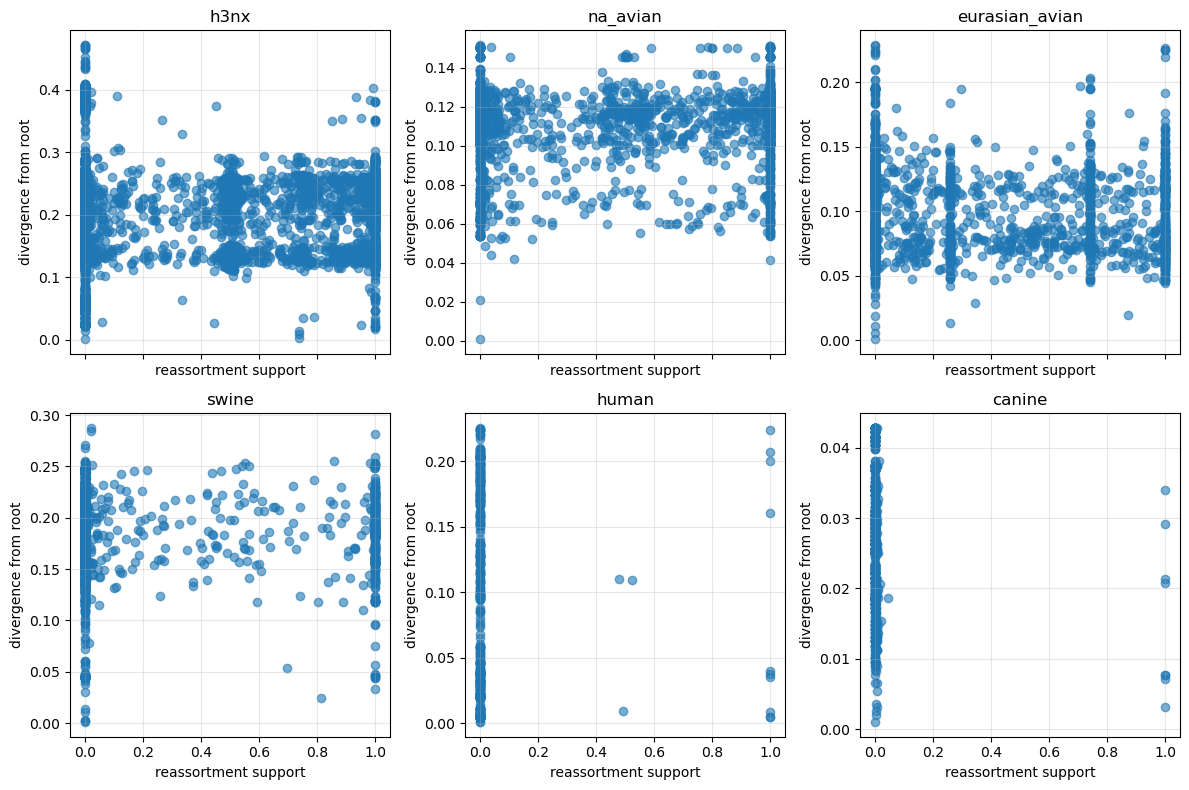

In [23]:
clades = df["clade"].unique()
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=False)

axes = axes.flatten()

for ax, clade in zip(axes, clades):
    subset = df[df["clade"] == clade]
    ax.scatter(subset["support"], subset["div"], alpha=0.6)
    ax.set_title(clade)
    ax.set_xlabel("reassortment support")
    ax.set_ylabel("divergence from root")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


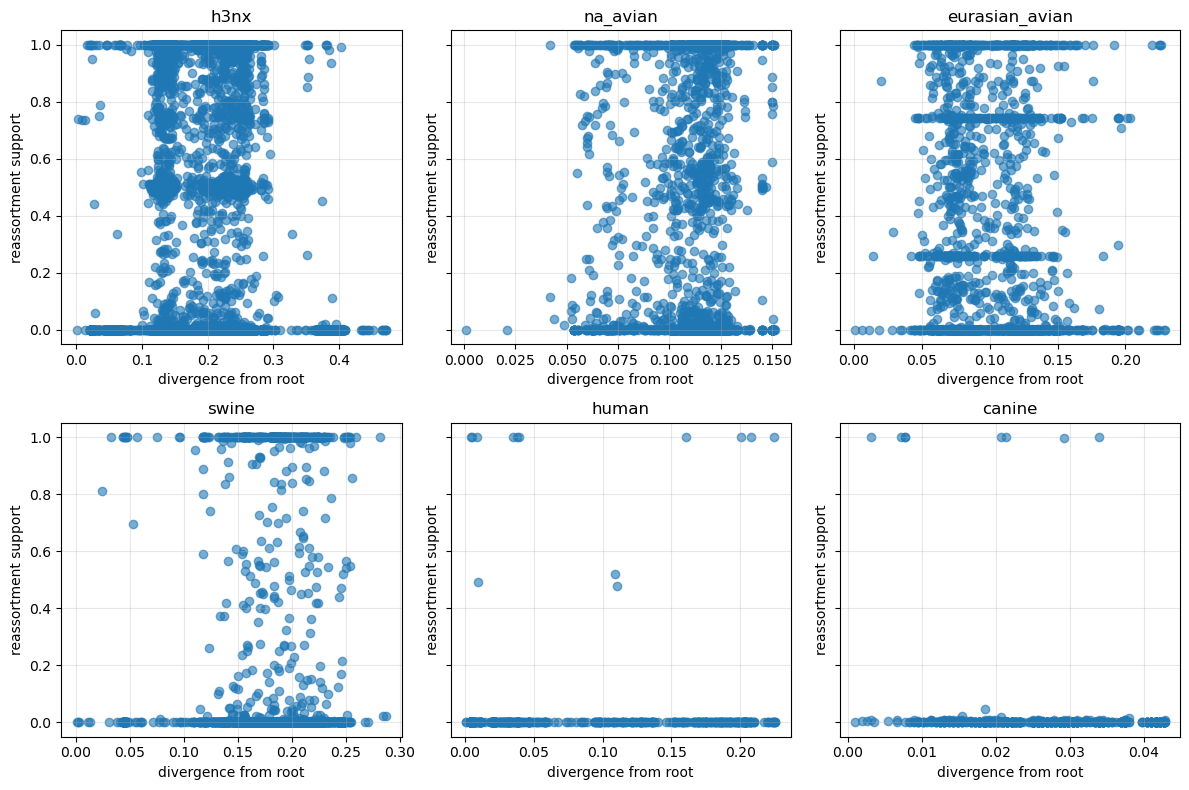

In [24]:
clades = df["clade"].unique()
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=False, sharey=True)

axes = axes.flatten()

for ax, clade in zip(axes, clades):
    subset = df[df["clade"] == clade]
    ax.scatter( subset["div"],subset["support"], alpha=0.6)
    ax.set_title(clade)
    ax.set_ylabel("reassortment support")
    ax.set_xlabel("divergence from root")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


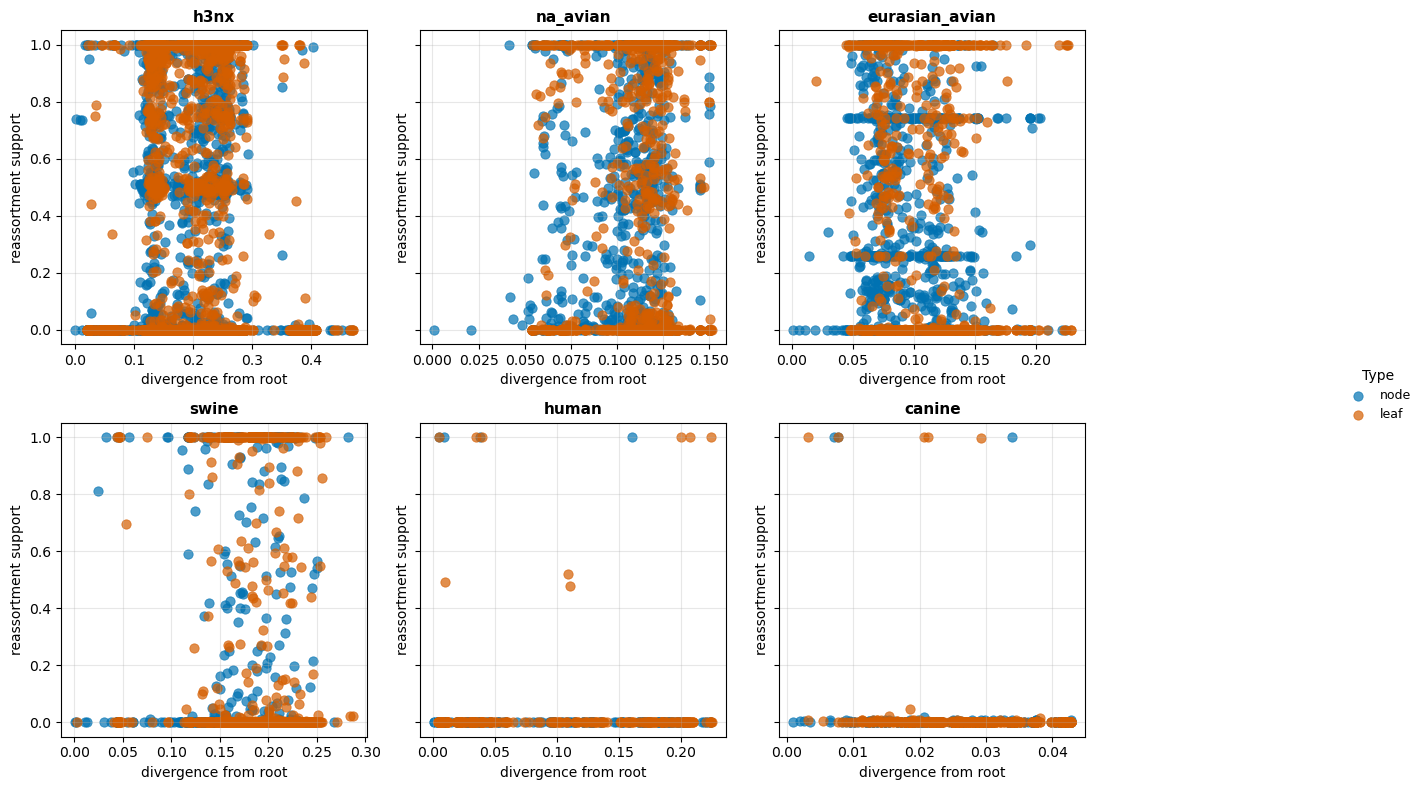

In [25]:
types = df["type"].unique()
colors = ["#0072B2", "#D55E00"]
color_map = dict(zip(types, colors))

clades = df["clade"].unique()
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=False, sharey=True)
axes = axes.flatten()

for ax, clade in zip(axes, clades):
    subset = df[df["clade"] == clade]
    for t in types:
        t_subset = subset[subset["type"] == t]
        ax.scatter(
            t_subset["div"],
            t_subset["support"],
            alpha=0.7,
            s=45,
            label=t,
            color=color_map[t],
            linewidth=0.6
        )
    ax.set_title(clade, fontsize=11, weight="semibold")
    ax.set_ylabel("reassortment support", fontsize=10)
    ax.set_xlabel("divergence from root", fontsize=10)
    ax.grid(True, alpha=0.3)

# Shared legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Type",
    loc="center left",
    bbox_to_anchor=(1.03, 0.5),
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

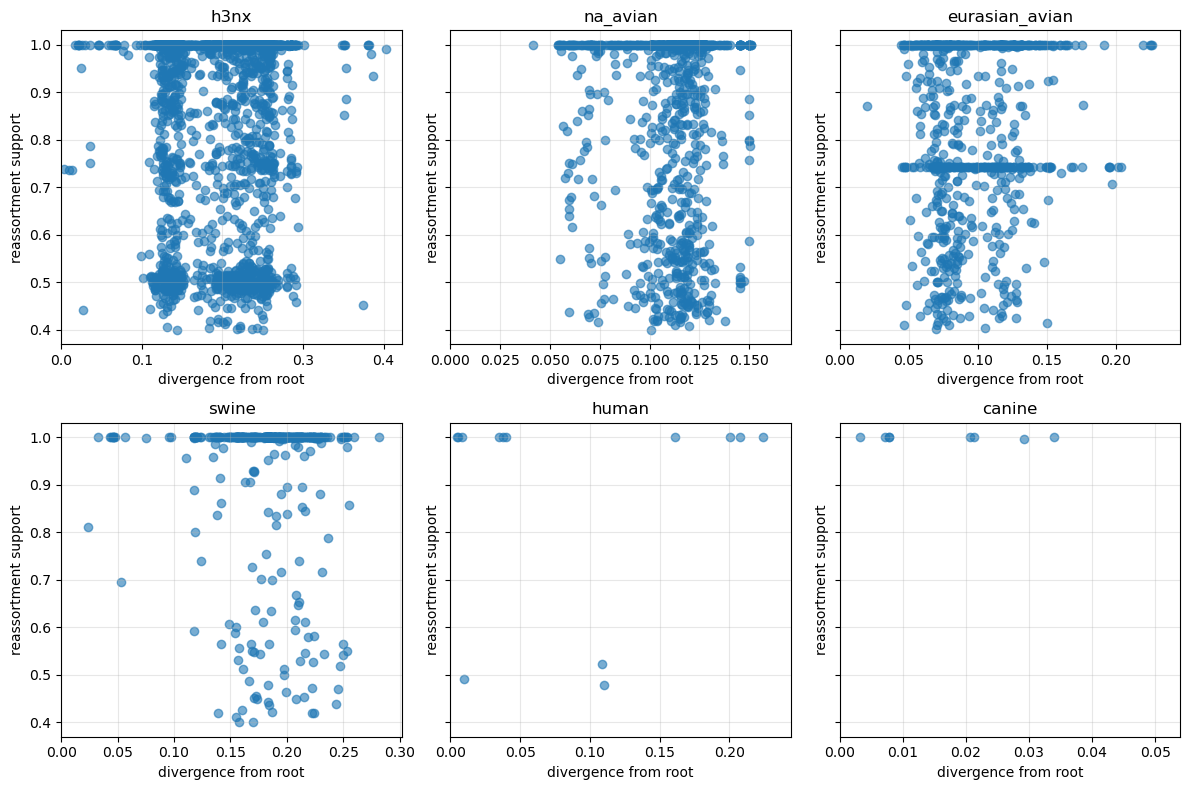

In [26]:
clades = df["clade"].unique()
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=False, sharey=True)

axes = axes.flatten()

for ax, clade in zip(axes, clades):
    subset = df[(df["clade"] == clade) & (df["support"] >= 0.40)]
    ax.scatter( subset["div"],subset["support"], alpha=0.6)
    ax.set_title(clade)
    ax.set_ylabel("reassortment support")
    ax.set_xlabel("divergence from root")
    ax.grid(True, alpha=0.3)
    
    x_max =  subset["div"].max()
    ax.set_xlim(0, x_max + 0.02) 

plt.tight_layout()
plt.show()


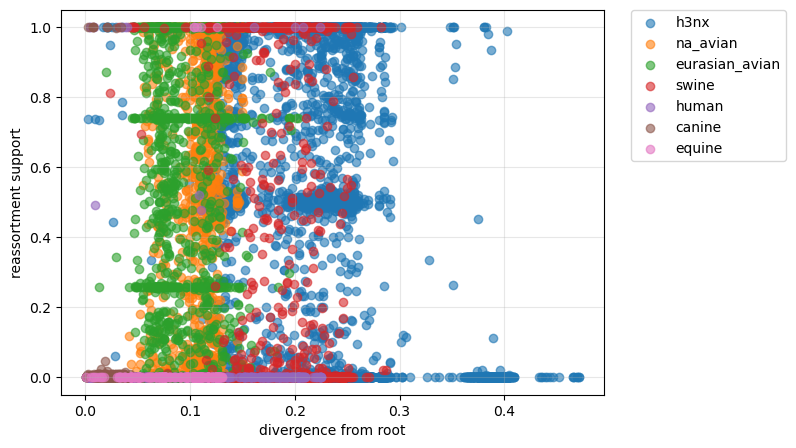

In [27]:
plt.figure(figsize=(7,5))
for clade in df["clade"].unique():
    subset = df[df["clade"] == clade]
    plt.scatter(subset["div"], subset["support"], label=clade, alpha=0.6)

plt.xlabel("divergence from root")
plt.ylabel("reassortment support")
plt.legend(
    bbox_to_anchor=(1.05, 1),  # position legend outside the plot (to the right)
    loc='upper left',
    borderaxespad=0.
)
plt.grid(True, alpha=0.3)
plt.show()


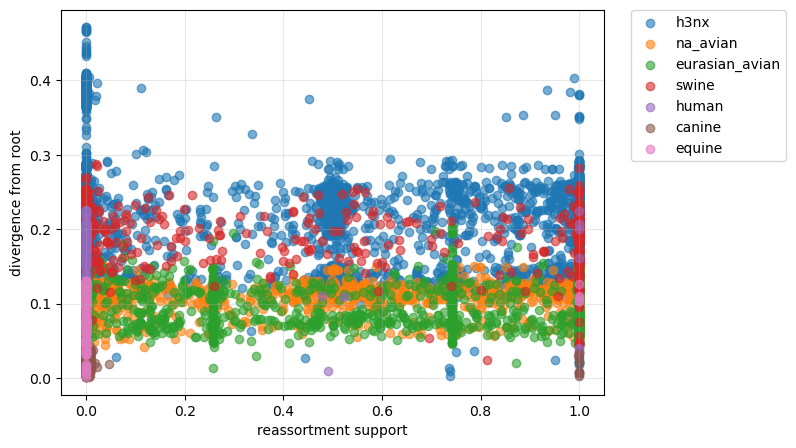

In [28]:
plt.figure(figsize=(7,5))
for clade in df["clade"].unique():
    subset = df[df["clade"] == clade]
    plt.scatter(subset["support"], subset["div"], label=clade, alpha=0.6)

plt.ylabel("divergence from root")
plt.xlabel("reassortment support")
plt.grid(True, alpha=0.3)
plt.legend(
    bbox_to_anchor=(1.05, 1),  # position legend outside the plot (to the right)
    loc='upper left',
    borderaxespad=0.
)
plt.show()

